In [218]:
import pandas as pd 
df = pd.read_csv("/Users/melina/Downloads/finalpaperdataset.csv")

In [219]:
import pickle 
with open("/Users/melina/Downloads/scalerF.pkl", "rb") as f:
    scaler = pickle.load(f)
print("Scaler Mean:", scaler.mean_)  
print("Scaler Scale:", scaler.scale_) 


Scaler Mean: [   3.75209923   57.46975385   62.92255385   58.18628462  270.39280769
 2022.97238462]
Scaler Scale: [2.27745204e-01 3.47220246e+01 2.71858629e+01 3.13093788e+01
 3.29498327e+02 1.54025687e+00]


In [220]:
import pandas as pd
import pickle

with open("/Users/melina/Downloads/scalerF.pkl", "rb") as f:
    scaler = pickle.load(f)


numeric_features = [
    'Applicant_GPA',
    'Target_University_FSR_Score',
    'Target_University_CPF_Score',
    'Target_University_ISR_Score',
    'Target_University_QS_Rank',
    'Decision_Year'
]

numeric_features = [col for col in numeric_features if col in df.columns]

df[numeric_features] = scaler.inverse_transform(df[numeric_features])

df.head()


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Program_Admission_Rate,Program_x_QS_Rank
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,1,1.0,1.0,0.027231,0.070154,0.005154,0.001077,0.629944,-0.018297
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,1,1.0,1.0,0.010385,0.010385,0.003385,0.001077,0.570370,-0.006473
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,1,2.0,1.0,0.083308,0.087077,0.010000,0.845308,0.541090,0.004199
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,1,2.0,1.0,0.082231,0.139077,0.005308,0.035846,0.670720,-0.065983
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,1,2.0,2.0,0.006308,0.006308,0.022154,0.845308,0.597561,-0.004927


In [221]:
import pandas as pd
import numpy as np
import pickle

with open('/Users/melina/Downloads/freq_mappingsF.pkl', 'rb') as f:
    freq_mappings = pickle.load(f)

decode_cols = {
    'Target_Program': 'Target_Program',
    'Target_Program_Discipline': 'Target_Program_Discipline',
    'Target_University': 'Target_University',
    'Target_Country': 'Target_Country'
}


def decode_freq_value(encoded_val, freq_dict):
   
    if pd.isna(encoded_val):
        return np.nan
  
    return min(
        freq_dict.items(),
        key=lambda x: abs(x[1] - encoded_val)
    )[0]

for df_col, mapping_key in decode_cols.items():
    if df_col in df.columns and mapping_key in freq_mappings:
        df[df_col.replace('_freq','')] = df[df_col].apply(
            lambda x: decode_freq_value(x, freq_mappings[mapping_key])
        )

df.head()


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Program_Admission_Rate,Program_x_QS_Rank
0,1,3.00,2025.0,53.0,100.0,23.5,49.0,1,1.0,1.0,Public Policy & Management,Politics & International Studies,"University of Maryland, Baltimore",China (Mainland),0.629944,-0.018297
1,1,3.33,2025.0,17.6,79.1,95.5,65.0,1,1.0,1.0,Geography,Geography,lausanne,China (Mainland),0.570370,-0.006473
2,1,3.85,2025.0,9.5,61.5,53.2,287.0,1,2.0,1.0,Computer Science,Computer Science & Information Systems,University of Arizona,United States of America,0.541090,0.004199
3,1,3.70,2025.0,100.0,88.6,93.1,6.0,1,2.0,1.0,Food and Resource Economics,Economics & Econometrics,pratt,United Kingdom,0.670720,-0.065983
4,0,3.94,2025.0,97.3,78.1,92.8,13.0,1,2.0,2.0,Film Studies,Performing Arts,University of Chicago,United States of America,0.597561,-0.004927


In [222]:

import pandas as pd 
country_counts = df["Target_Country"].value_counts()

country_distribution = (country_counts / len(df)) * 100

import pandas as pd
country_distribution_df = pd.DataFrame({
    "Count": country_counts,
    "Percentage": country_distribution
})

country_distribution_df.head(10) 


,Count,Percentage
Target_Country,,
United States of America,10989,84.530769
Canada,708,5.446154
United Kingdom,466,3.584615
Switzerland,148,1.138462
Germany,70,0.538462
Italy,62,0.476923
Spain,61,0.469231
Australia,57,0.438462
Republic of Korea,52,0.400000


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


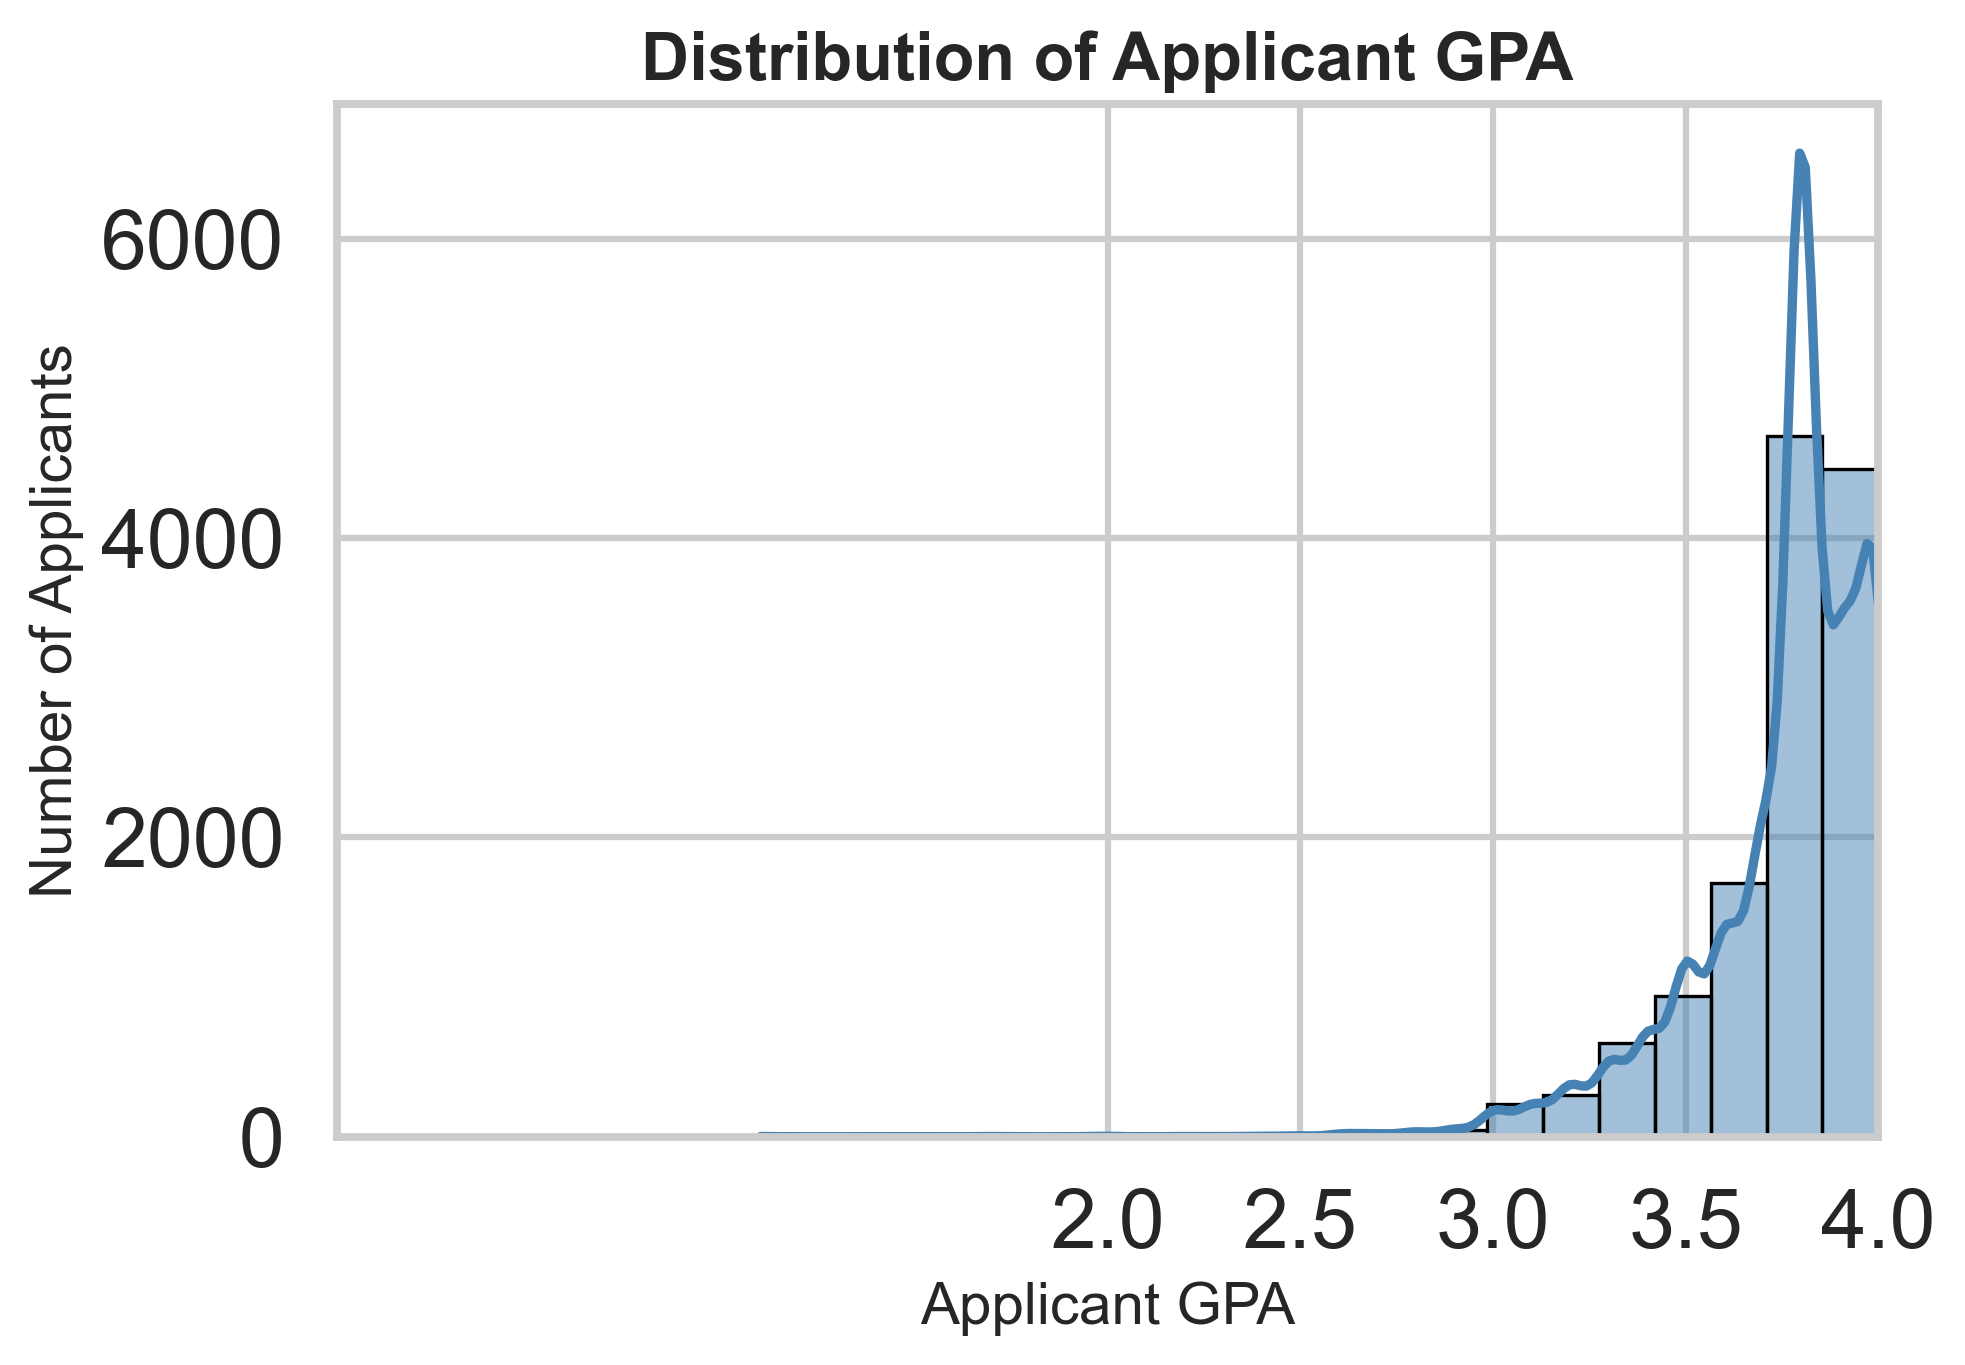

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", context="talk", font_scale=1.2)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300) 

sns.histplot(
    df['Applicant_GPA'],
    bins=20,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

ax.set_xlim(0, 4)
ax.set_xticks(np.arange(2, 4.1, 0.5))

ax.set_xlabel("Applicant GPA", fontsize=14)
ax.set_ylabel("Number of Applicants", fontsize=14)
ax.set_title("Distribution of Applicant GPA", fontsize=16, weight='bold')

plt.tight_layout()

plt.savefig("applicant_gpa_distribution.pdf", format='pdf', bbox_inches='tight')

plt.show()


In [224]:
import pandas as pd

gpa_stats = df['Applicant_GPA'].describe().to_frame().T  
gpa_stats['Variance'] = df['Applicant_GPA'].var()
gpa_stats['Skewness'] = df['Applicant_GPA'].skew()
gpa_stats['Kurtosis'] = df['Applicant_GPA'].kurtosis()

gpa_stats = gpa_stats.round(3)

print(gpa_stats)


                 count   mean    std  min   25%  50%  75%  max  Variance  \
Applicant_GPA  13000.0  3.752  0.228  1.1  3.68  3.8  3.9  4.0     0.052   

               Skewness  Kurtosis  
Applicant_GPA    -1.793     5.483  


/var/folders/9z/cd_vb_mn5lgbg_j114xlcmp00000gn/T/ipykernel_39372/1291656175.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_means = df.groupby(f'{feature}_quantile')['Decision'].mean()
/var/folders/9z/cd_vb_mn5lgbg_j114xlcmp00000gn/T/ipykernel_39372/1291656175.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_means = df.groupby(f'{feature}_quantile')[feature].mean()
/var/folders/9z/cd_vb_mn5lgbg_j114xlcmp00000gn/T/ipykernel_39372/1291656175.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

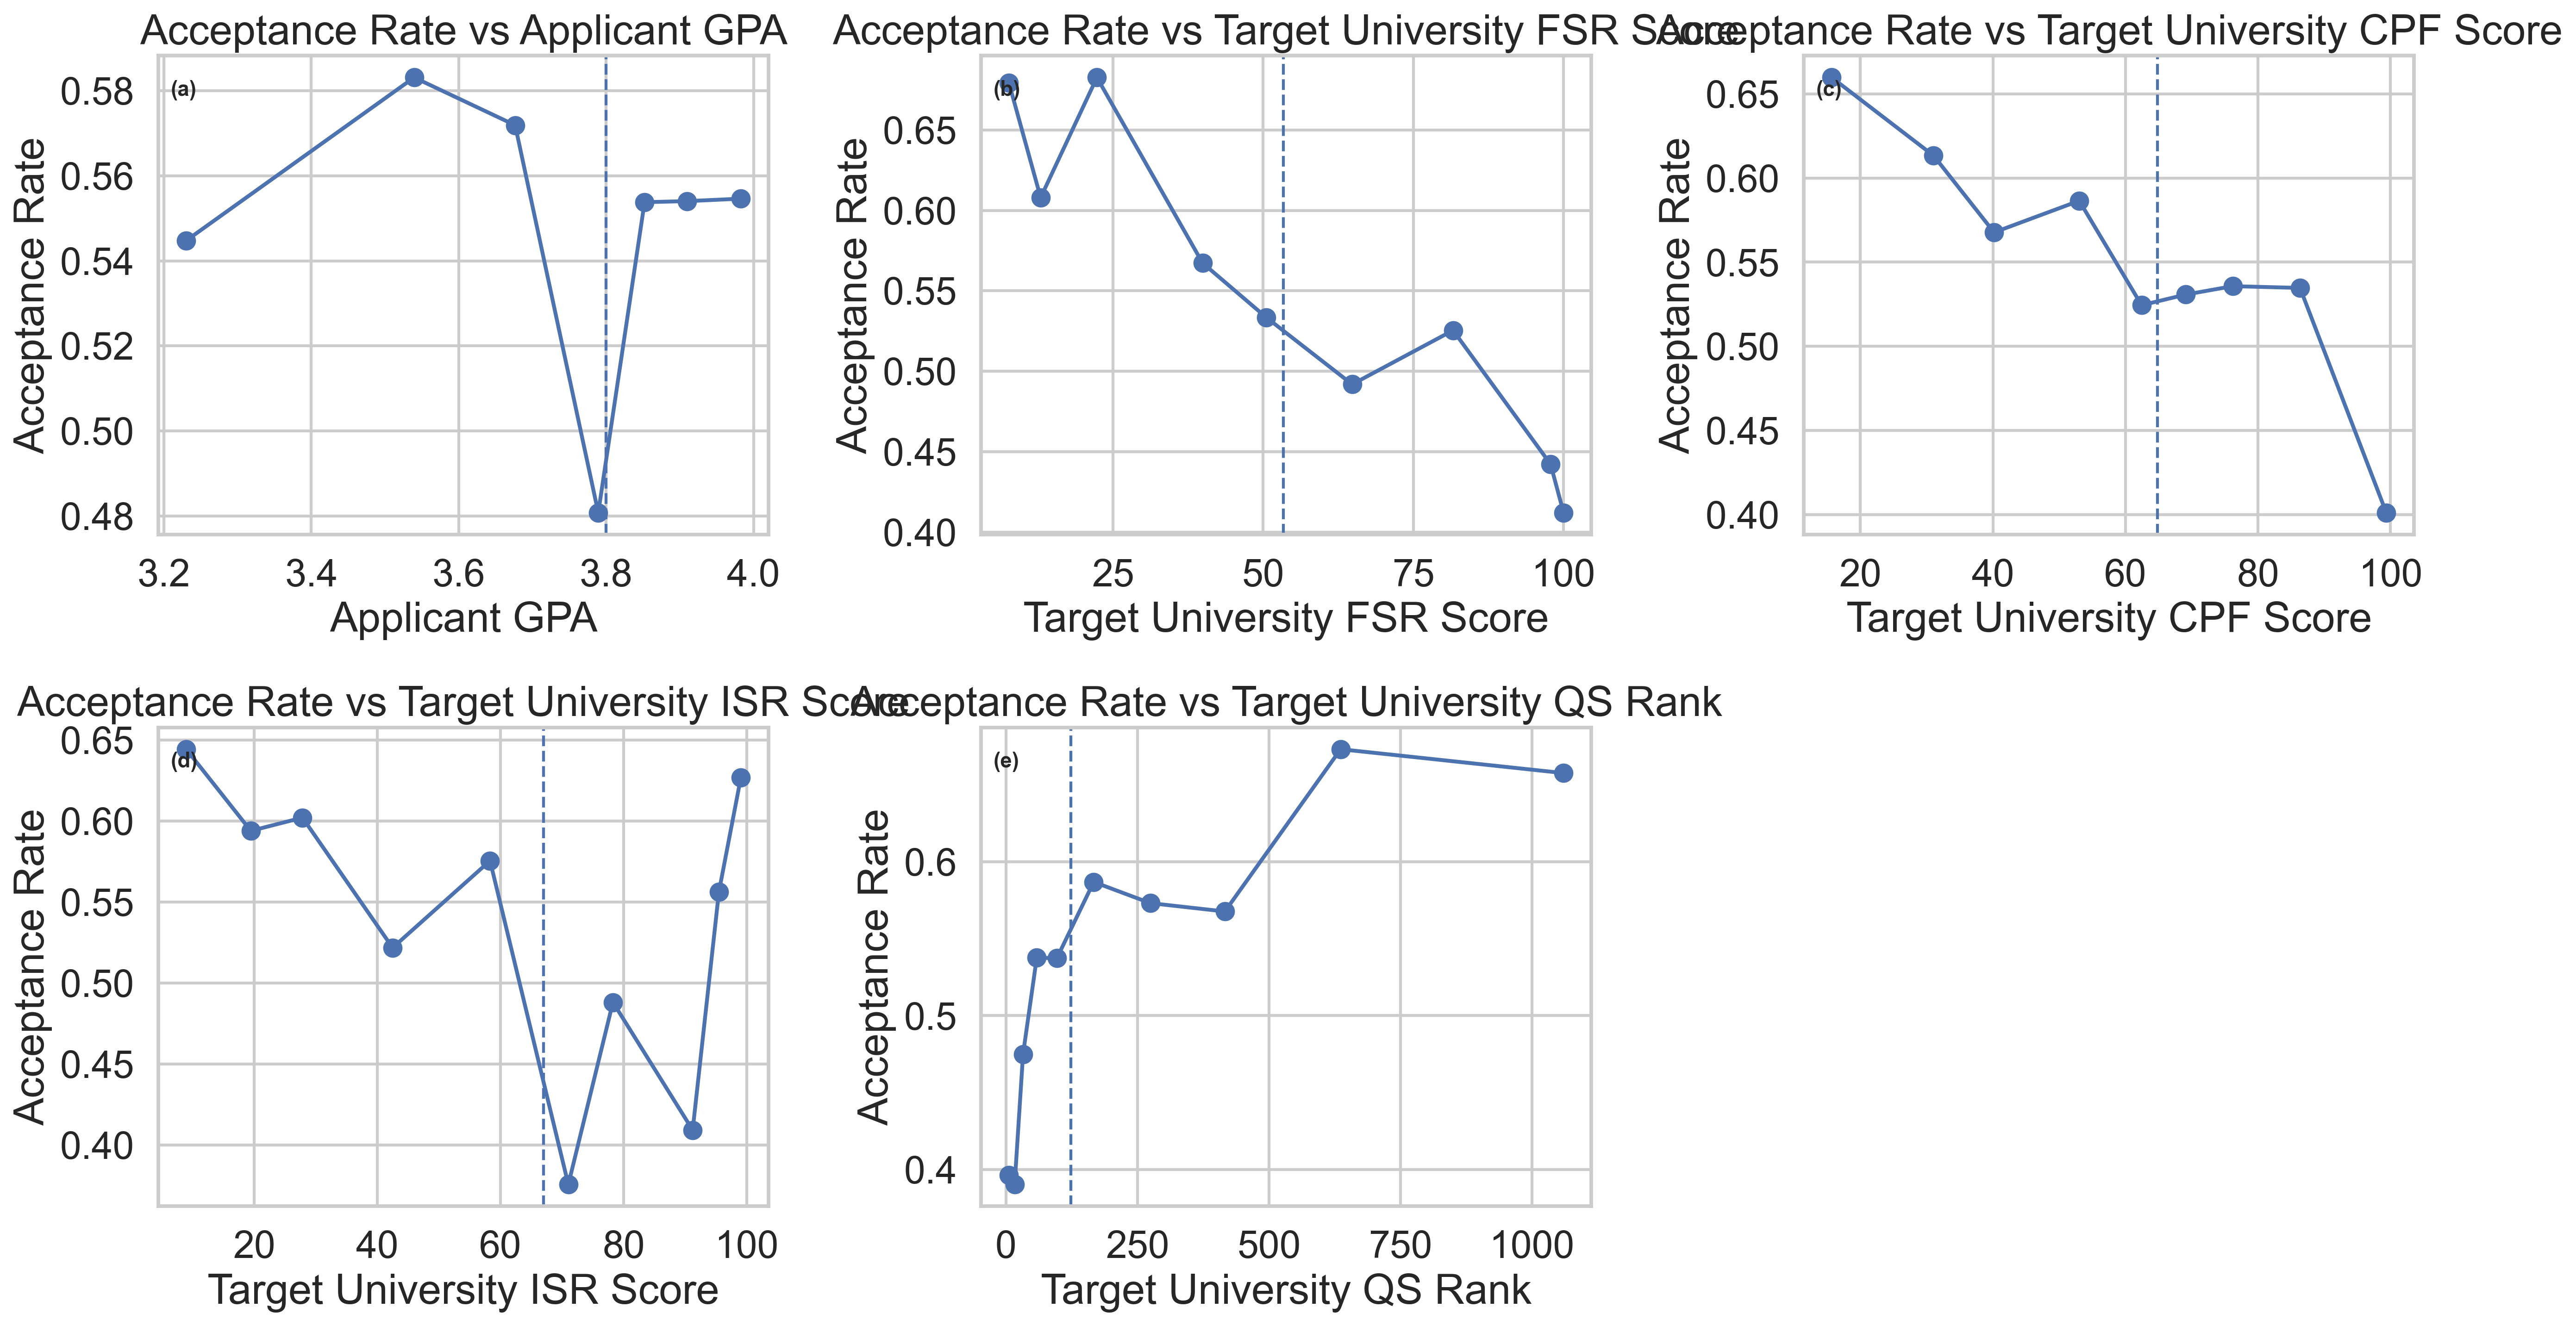

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string


features = [
    'Applicant_GPA',
    'Target_University_FSR_Score',
    'Target_University_CPF_Score',
    'Target_University_ISR_Score',
    'Target_University_QS_Rank'
]


thresholds = {
    feature: df[feature].median()
    for feature in features
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

panel_labels = [f'({c})' for c in string.ascii_lowercase]

for i, feature in enumerate(features):
 
    df[f'{feature}_quantile'] = pd.qcut(
        df[feature],
        q=10,
        duplicates='drop'
    )

    acceptance_means = df.groupby(f'{feature}_quantile')['Decision'].mean()

    quantile_means = df.groupby(f'{feature}_quantile')[feature].mean()

    axes[i].plot(
        quantile_means,
        acceptance_means.values,
        marker='o',
        linewidth=2
    )

    axes[i].axvline(
        x=thresholds[feature],
        linestyle='--',
        linewidth=1.5
    )

    axes[i].set_title(f'Acceptance Rate vs {feature.replace("_", " ")}')
    axes[i].set_xlabel(feature.replace("_", " "))
    axes[i].set_ylabel('Acceptance Rate')
    axes[i].grid(True)

    axes[i].text(
        0.02,
        0.95,
        f'{panel_labels[i]}',
        transform=axes[i].transAxes,
        fontsize=11,
        fontweight='bold',
        va='top'
    )

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [226]:
import pandas as pd

USA = "United States of America"
ACCEPTED = 1

STATUS_INTERNATIONAL = 1
STATUS_AMERICAN = 2

DEGREE_MASTERS = 1
DEGREE_PHD = 2

PUBLIC = 1
PRIVATE_NOT_FOR_PROFIT = 2
PRIVATE_FOR_PROFIT = 3

total_rows = len(df)

us_mask = df["Target_Country"] == USA
non_us_mask = ~us_mask

pct_us_universities = us_mask.mean() * 100
pct_other_universities = non_us_mask.mean() * 100

pct_intl_to_us = (
    ((df["Applicant_Status"] == STATUS_INTERNATIONAL) & us_mask).mean() * 100
)

pct_intl_to_non_us = (
    ((df["Applicant_Status"] == STATUS_INTERNATIONAL) & non_us_mask).mean() * 100
)

pct_american_to_us = (
    ((df["Applicant_Status"] == STATUS_AMERICAN) & us_mask).mean() * 100
)

pct_american_to_non_us = (
    ((df["Applicant_Status"] == STATUS_AMERICAN) & non_us_mask).mean() * 100
)

pct_american_students = (
    df["Applicant_Status"].eq(STATUS_AMERICAN).mean() * 100
)

pct_international_students = (
    df["Applicant_Status"].eq(STATUS_INTERNATIONAL).mean() * 100
)

acceptance_rate_us = (
    df.loc[us_mask, "Decision"].eq(ACCEPTED).mean() * 100
)

acceptance_rate_non_us = (
    df.loc[non_us_mask, "Decision"].eq(ACCEPTED).mean() * 100
)

pct_masters = (
    df["Target_Degree_Type"].eq(DEGREE_MASTERS).mean() * 100
)

pct_phd = (
    df["Target_Degree_Type"].eq(DEGREE_PHD).mean() * 100
)

pct_public = (
    df["Target_University_Status"].eq(PUBLIC).mean() * 100
)

pct_private_not_for_profit = (
    df["Target_University_Status"].eq(PRIVATE_NOT_FOR_PROFIT).mean() * 100
)

pct_private_for_profit = (
    df["Target_University_Status"].eq(PRIVATE_FOR_PROFIT).mean() * 100
)

results = pd.Series({
    "percentage of rows dedicated to Us universities": pct_us_universities,
    "percentage of rows dedicated to other universities": pct_other_universities,
    "international students choosing american universities": pct_intl_to_us,
    "international students choosing other universities": pct_intl_to_non_us,
    "american students choosing american universities": pct_american_to_us,
    "american students choosing international universities": pct_american_to_non_us,
    "percentage of american students": pct_american_students,
    "percentage of international students": pct_international_students,
    "acceptance rate in american universities": acceptance_rate_us,
    "acceptance rate in other universities": acceptance_rate_non_us,
    "percentage of rows dedictaed to master": pct_masters,
    "percentage of rows dedicated to phd": pct_phd,
    "percentage of rows for private for profit universities": pct_private_for_profit,
    "percentage of rows for private not for profit universities": pct_private_not_for_profit,
    "percentage of rows for public universities": pct_public
}).round(2)

results


percentage of rows dedicated to Us universities               84.53
percentage of rows dedicated to other universities            15.47
international students choosing american universities         41.42
international students choosing other universities            10.57
american students choosing american universities              43.12
american students choosing international universities          4.90
percentage of american students                               48.02
percentage of international students                          51.98
acceptance rate in american universities                      51.73
acceptance rate in other universities                         64.00
percentage of rows dedictaed to master                        36.79
percentage of rows dedicated to phd                           63.21
percentage of rows for private for profit universities         0.51
percentage of rows for private not for profit universities    44.88
percentage of rows for public universities      

In [227]:
import pandas as pd

program_distribution = (
    df["Target_Program"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

discipline_distribution = (
    df["Target_Program_Discipline"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

program_distribution, discipline_distribution


(Target_Program
 Computer Science                        8.33
 Food and Resource Economics             8.22
 Economics                               5.52
 Physics                                 4.14
 Speech-Language Pathology               3.98
                                         ... 
 Industrial-Organizational Psychology    0.26
 Religious Studies                       0.22
 Information Science                     0.21
 Cognitive Psychology                    0.16
 Microbiology                            0.15
 Name: proportion, Length: 73, dtype: float64,
 Target_Program_Discipline
 Economics & Econometrics                                  13.91
 Computer Science & Information Systems                     8.71
 Politics & International Studies                           7.02
 Physics & Astronomy                                        6.15
 Engineering – Electrical & Electronic                      5.35
 Life Sciences & Medicine                                   4.89
 Biological Sc

Program Distribution (%):
 Computer Science                8.33
Food and Resource Economics     8.22
Economics                       5.52
Physics                         4.14
Speech-Language Pathology       3.98
Chemistry                       3.35
Philosophy                      3.05
Public Policy & Management      2.72
English                         2.68
Political Science               2.31
Other                          55.72
dtype: float64 

Discipline Distribution (%):
 Economics & Econometrics                                  13.91
Computer Science & Information Systems                     8.71
Politics & International Studies                           7.02
Physics & Astronomy                                        6.15
Engineering – Electrical & Electronic                      5.35
Life Sciences & Medicine                                   4.89
Biological Sciences                                        4.22
Education                                                  4.01
Psychol

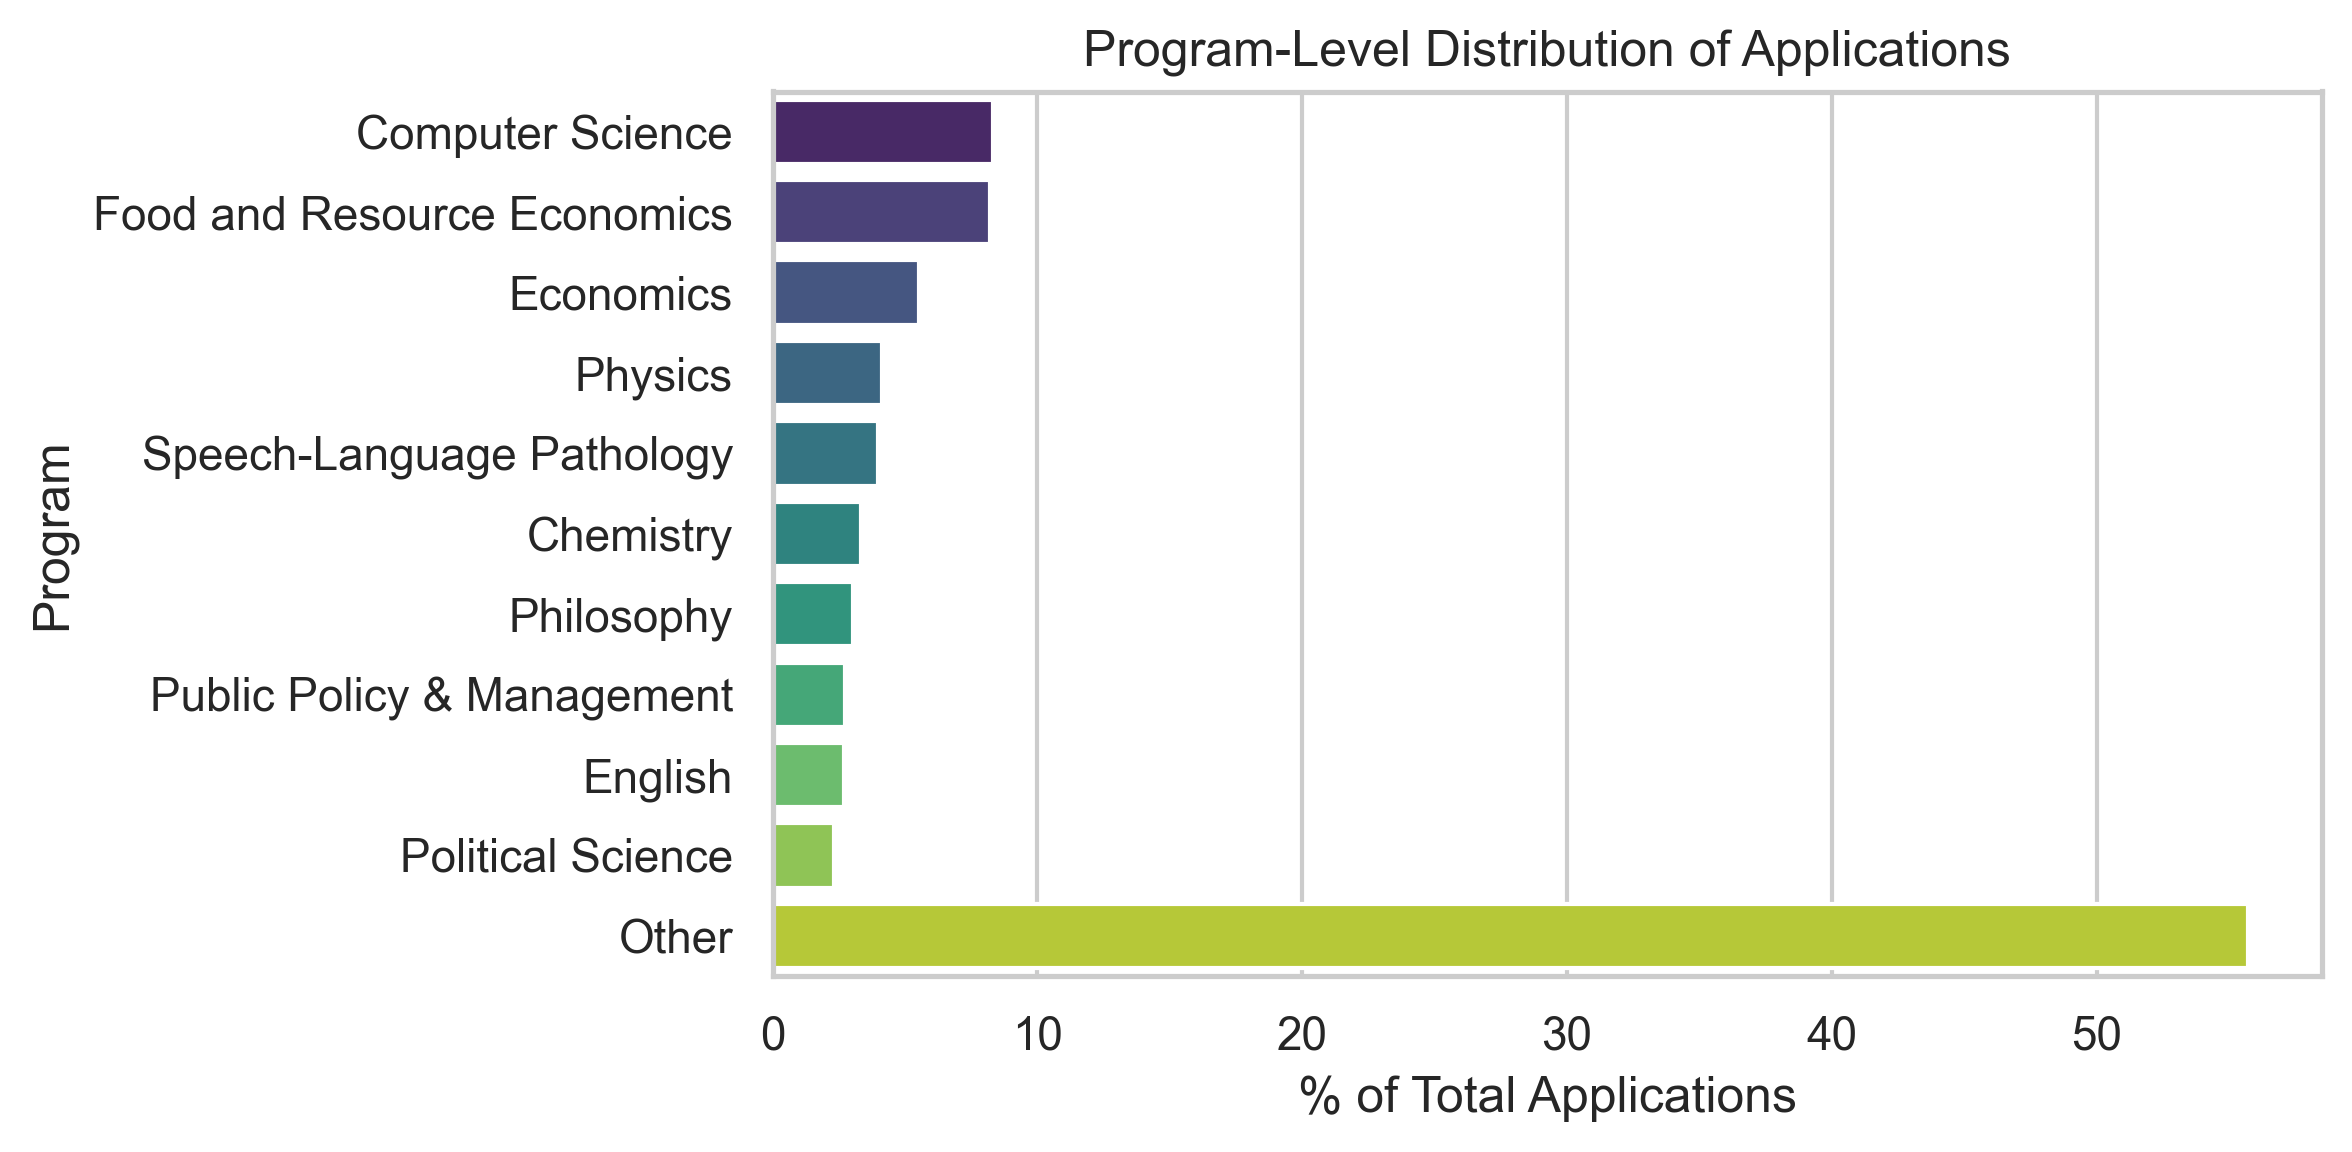

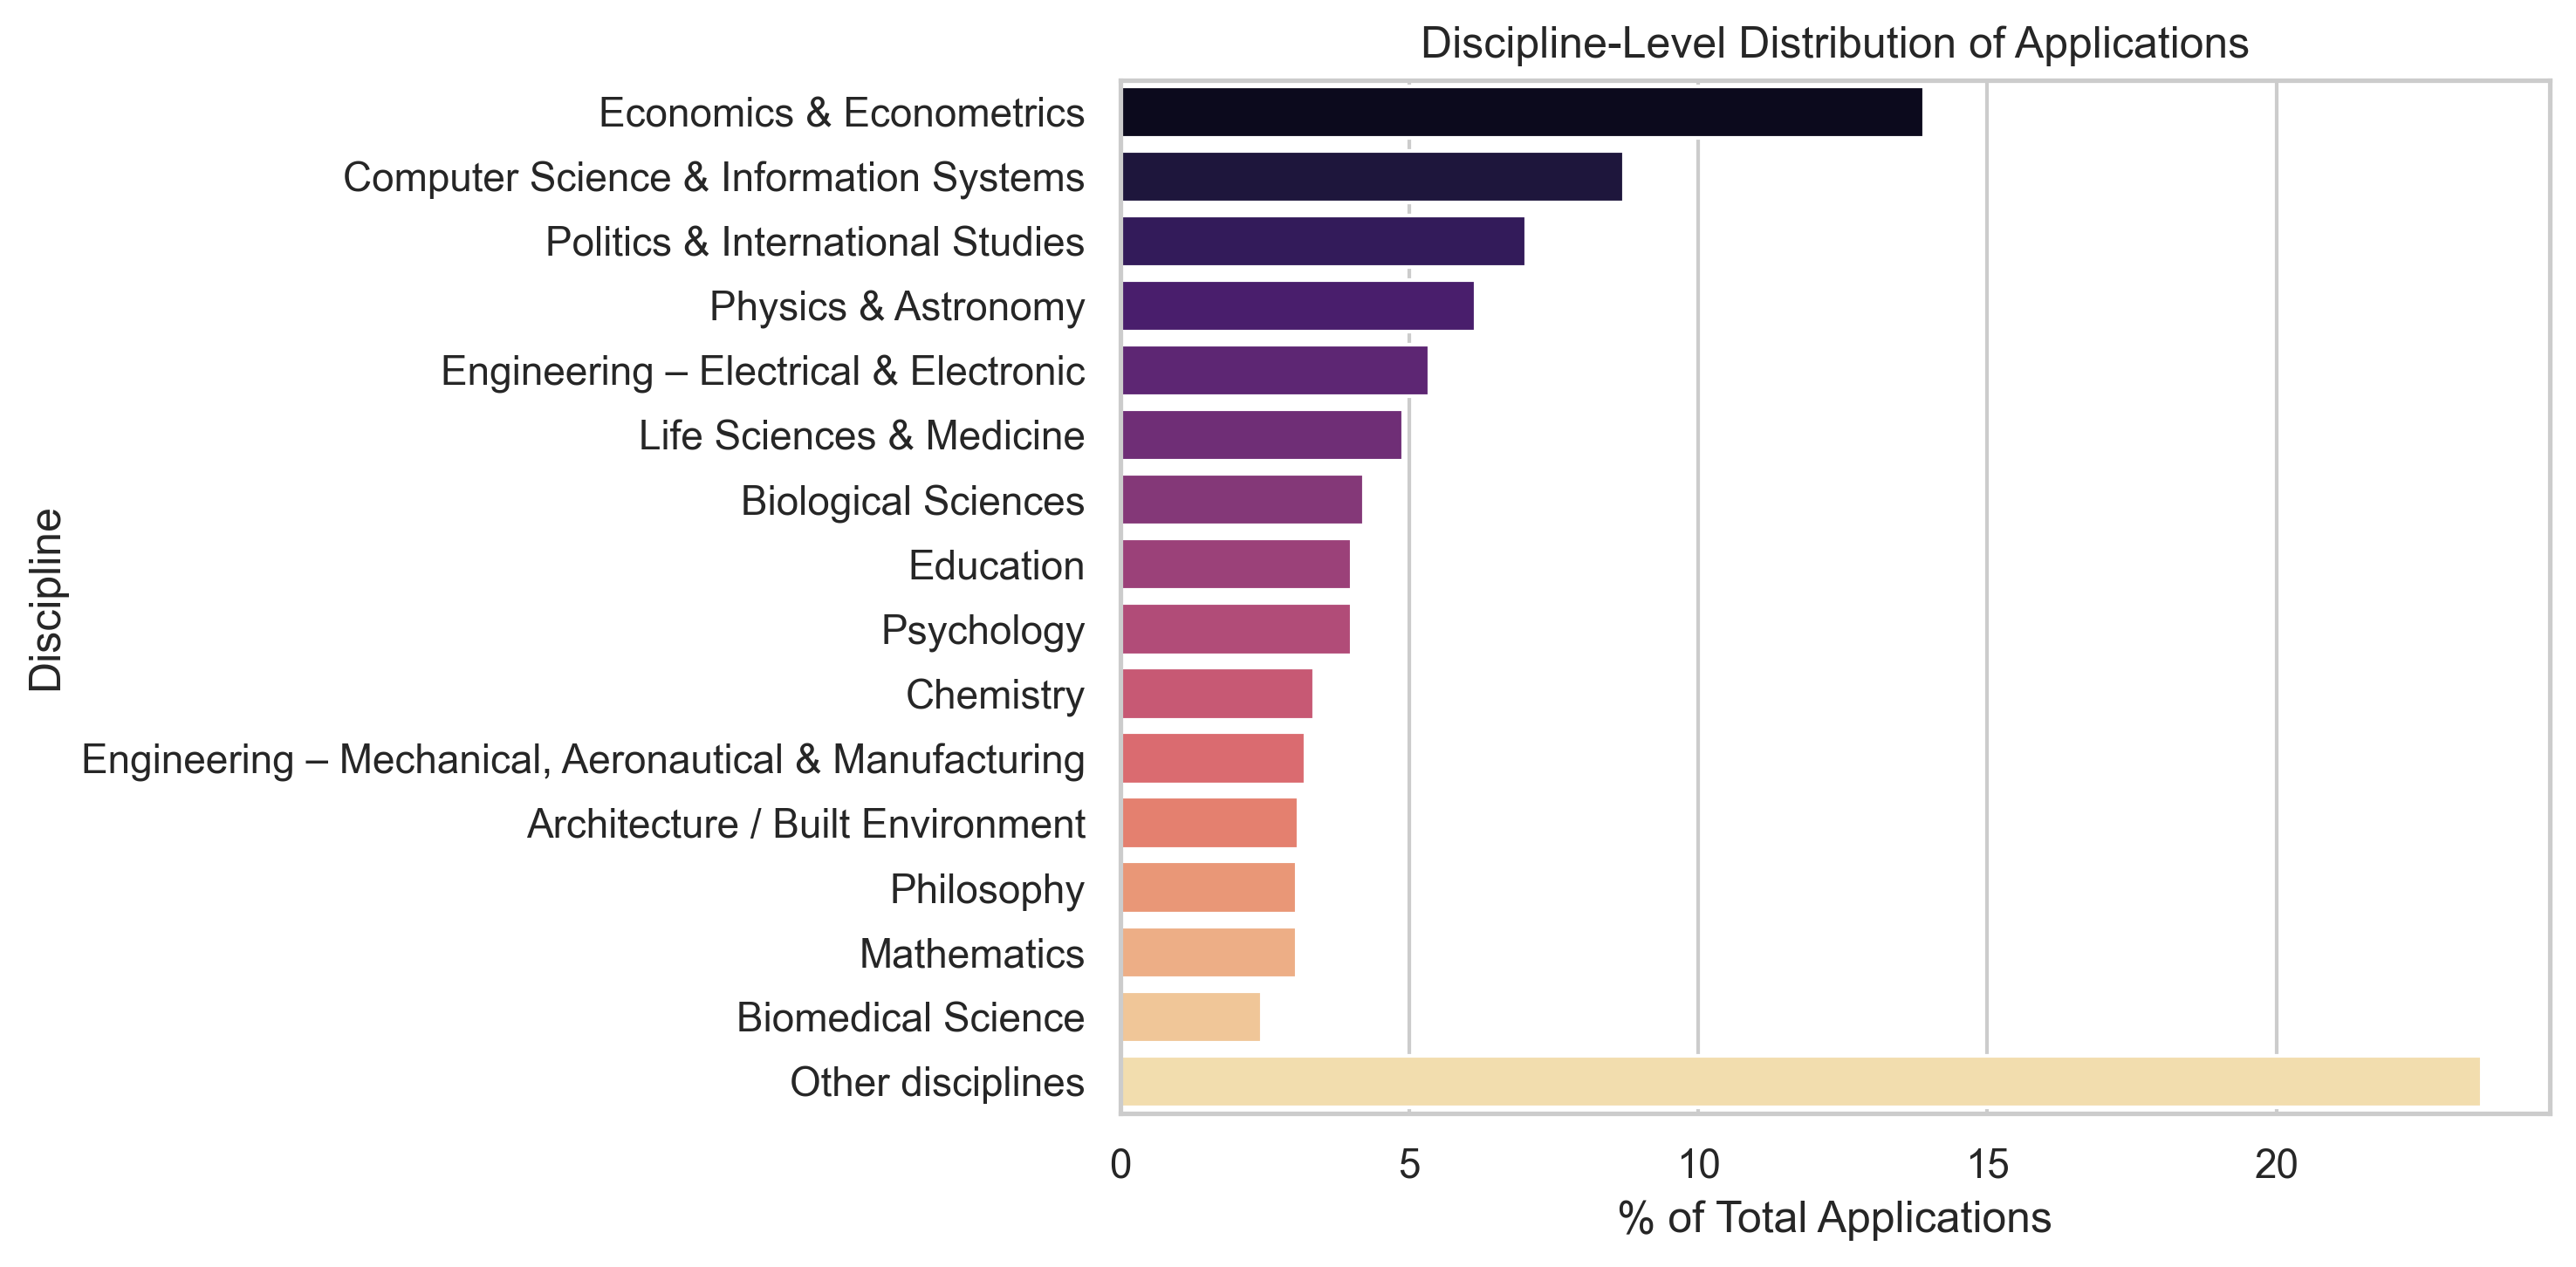

In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_k_programs = 10     
top_k_disciplines = 15  

program_dist = df["Target_Program"].value_counts(normalize=True) * 100
program_dist = program_dist.round(2)

program_top = program_dist.head(top_k_programs)

program_other = pd.Series({'Other': round(program_dist[top_k_programs:].sum(), 2)})

program_table = pd.concat([program_top, program_other])

discipline_dist = df["Target_Program_Discipline"].value_counts(normalize=True) * 100
discipline_dist = discipline_dist.round(2)

discipline_top = discipline_dist.head(top_k_disciplines)

discipline_other = pd.Series({'Other disciplines': round(discipline_dist[top_k_disciplines:].sum(), 2)})

discipline_table = pd.concat([discipline_top, discipline_other])

print("Program Distribution (%):\n", program_table, "\n")
print("Discipline Distribution (%):\n", discipline_table, "\n")

sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(x=program_table.values, y=program_table.index, palette="viridis")
plt.xlabel("% of Total Applications")
plt.ylabel("Program")
plt.title("Program-Level Distribution of Applications")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=discipline_table.values, y=discipline_table.index, palette="magma")
plt.xlabel("% of Total Applications")
plt.ylabel("Discipline")
plt.title("Discipline-Level Distribution of Applications")
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


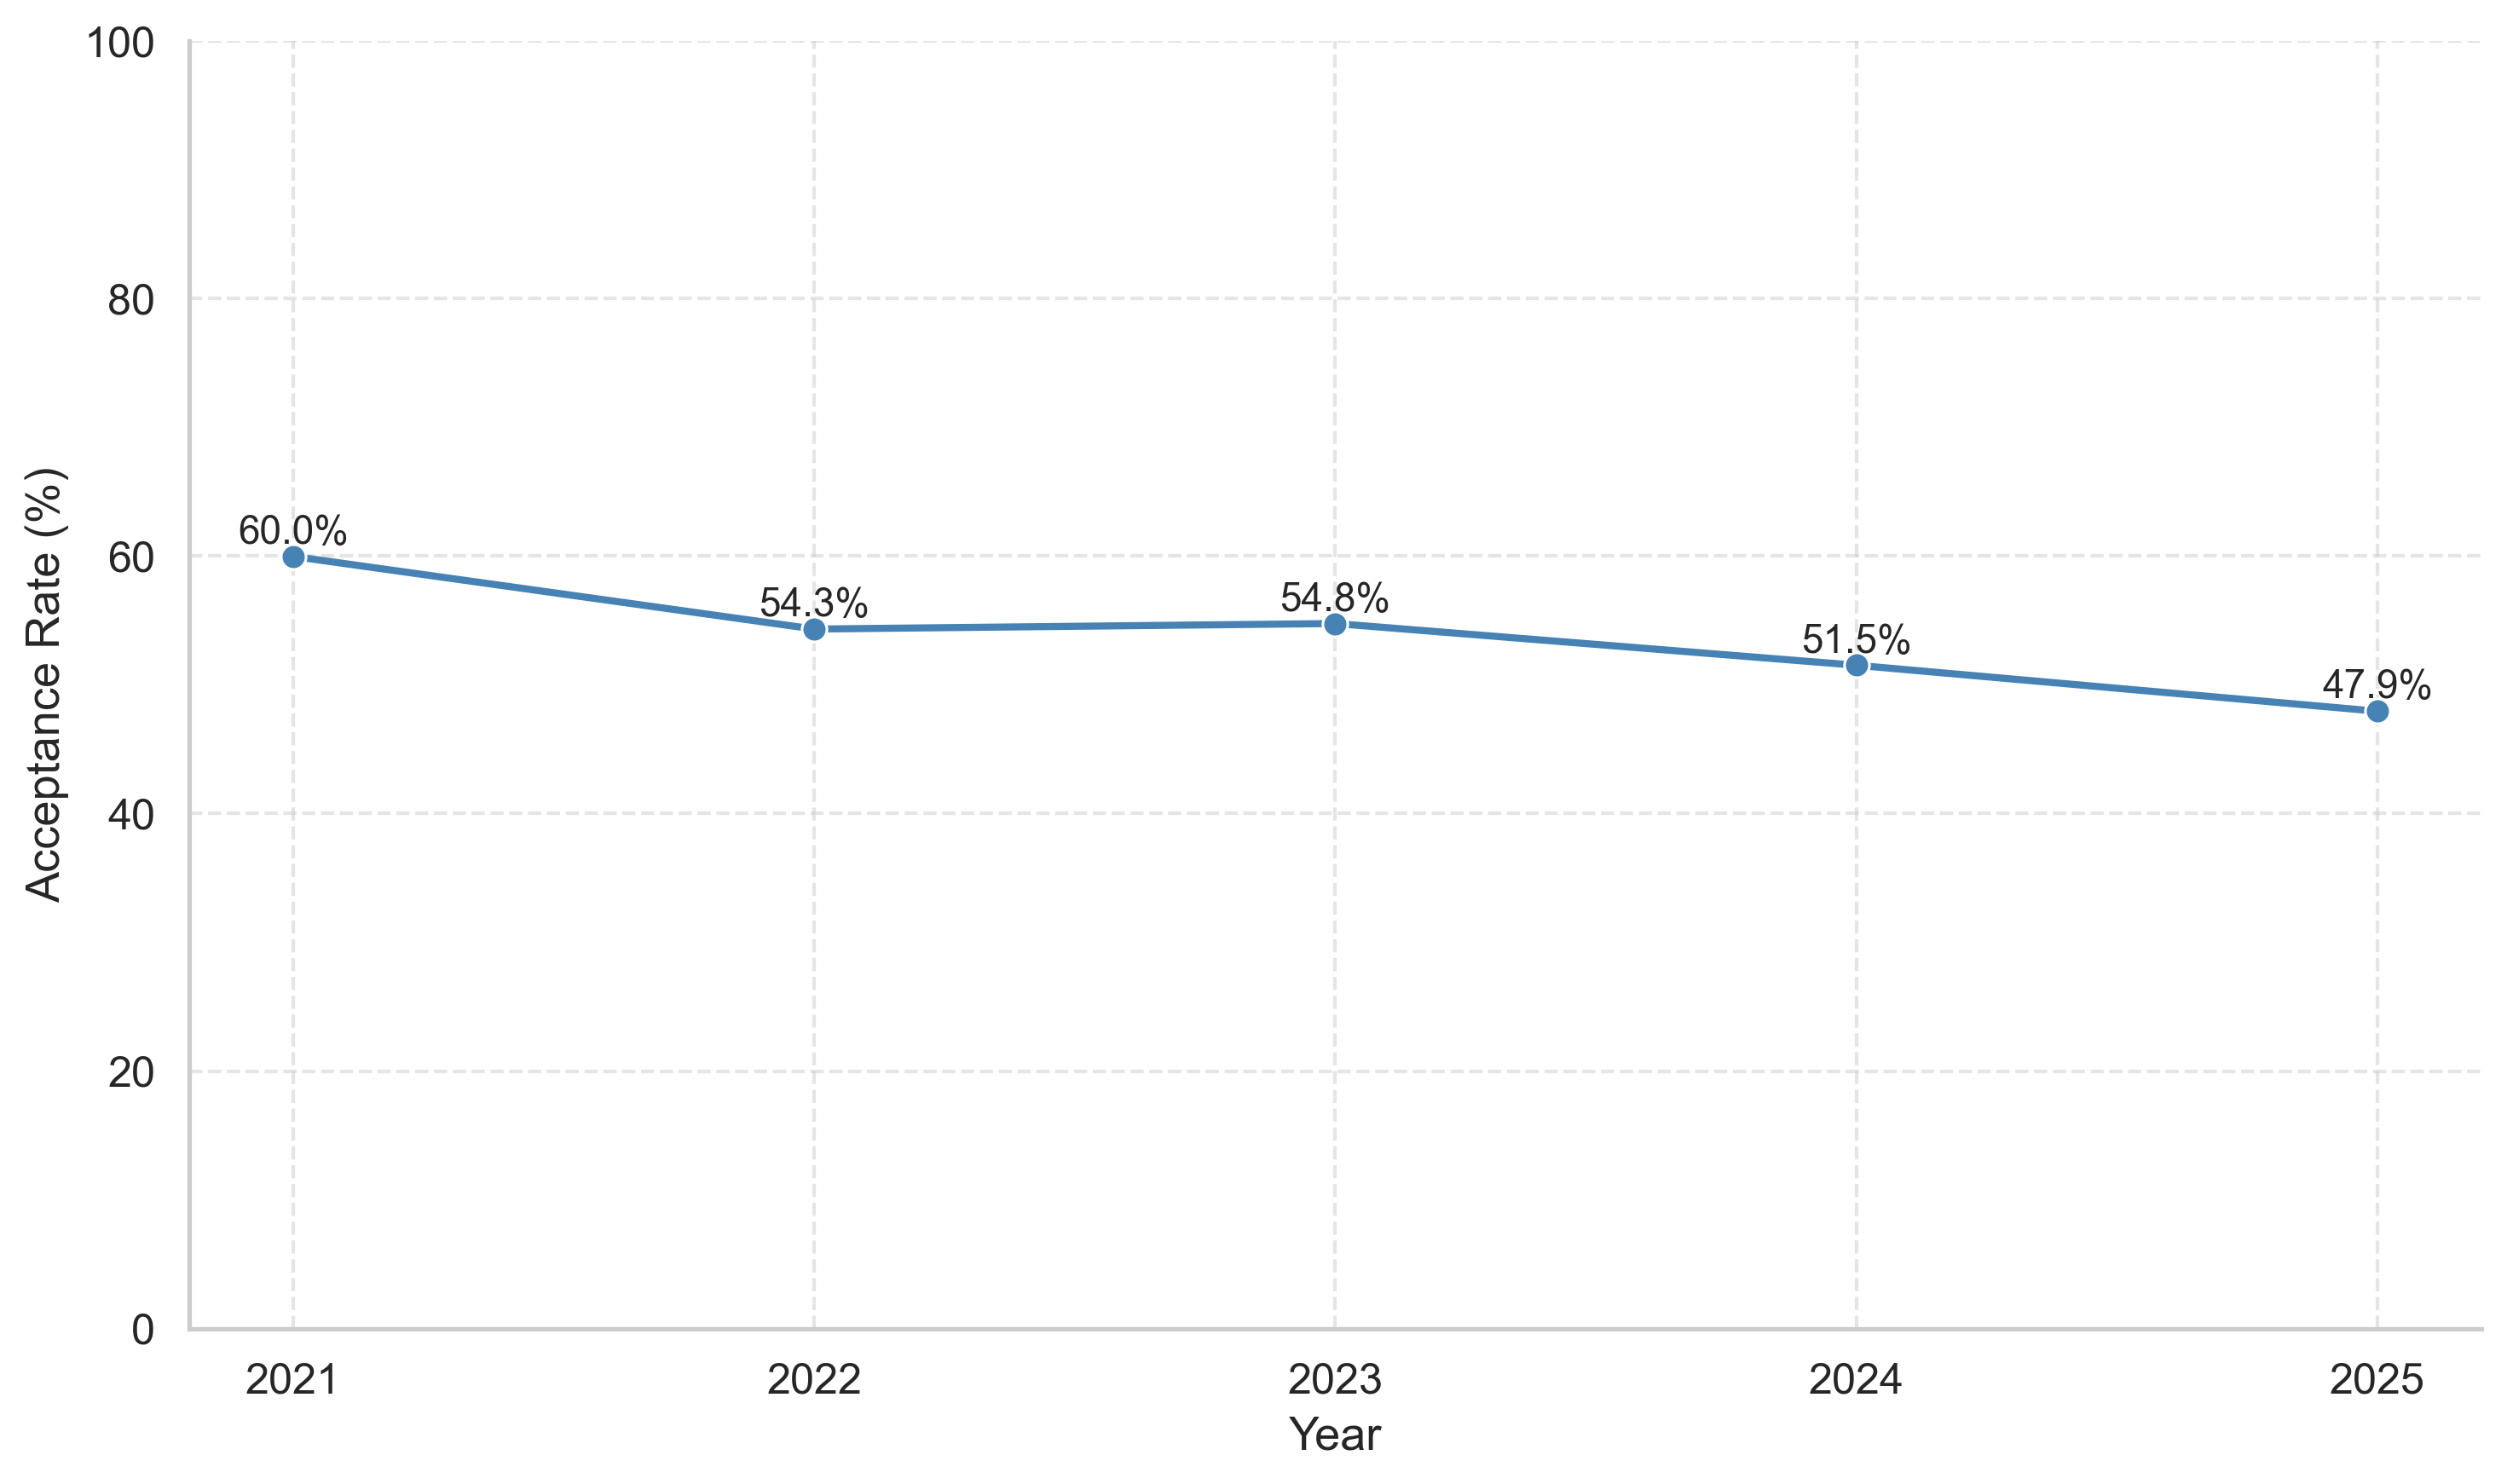

In [229]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ACCEPTED = 1

acceptance_by_year = (
    df.groupby("Decision_Year")["Decision"]
    .apply(lambda x: (x == ACCEPTED).mean() * 100)
    .round(2)
    .reset_index()
    .rename(columns={"Decision": "Acceptance_Rate"})
)

acceptance_by_year["Decision_Year"] = acceptance_by_year["Decision_Year"].astype(int)

sns.set(style="whitegrid", context="notebook", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.lineplot(
    data=acceptance_by_year,
    x="Decision_Year",
    y="Acceptance_Rate",
    marker="o",
    color="steelblue",
    linewidth=2,
    markersize=7,
    ax=ax
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Acceptance Rate (%)", fontsize=13)

ax.set_xticks(acceptance_by_year["Decision_Year"])
ax.set_xticklabels(acceptance_by_year["Decision_Year"], rotation=0)

ax.set_ylim(0, 100)

ax.grid(True, linestyle='--', alpha=0.5)
sns.despine(ax=ax, top=True, right=True)

for x, y in zip(acceptance_by_year["Decision_Year"], acceptance_by_year["Acceptance_Rate"]):
    ax.text(x, y + 1, f"{y:.1f}%", ha='center', fontsize=11)

plt.tight_layout()

plt.savefig("acceptance_rate_over_years_horizontal.pdf", format='pdf', bbox_inches='tight')

plt.show()


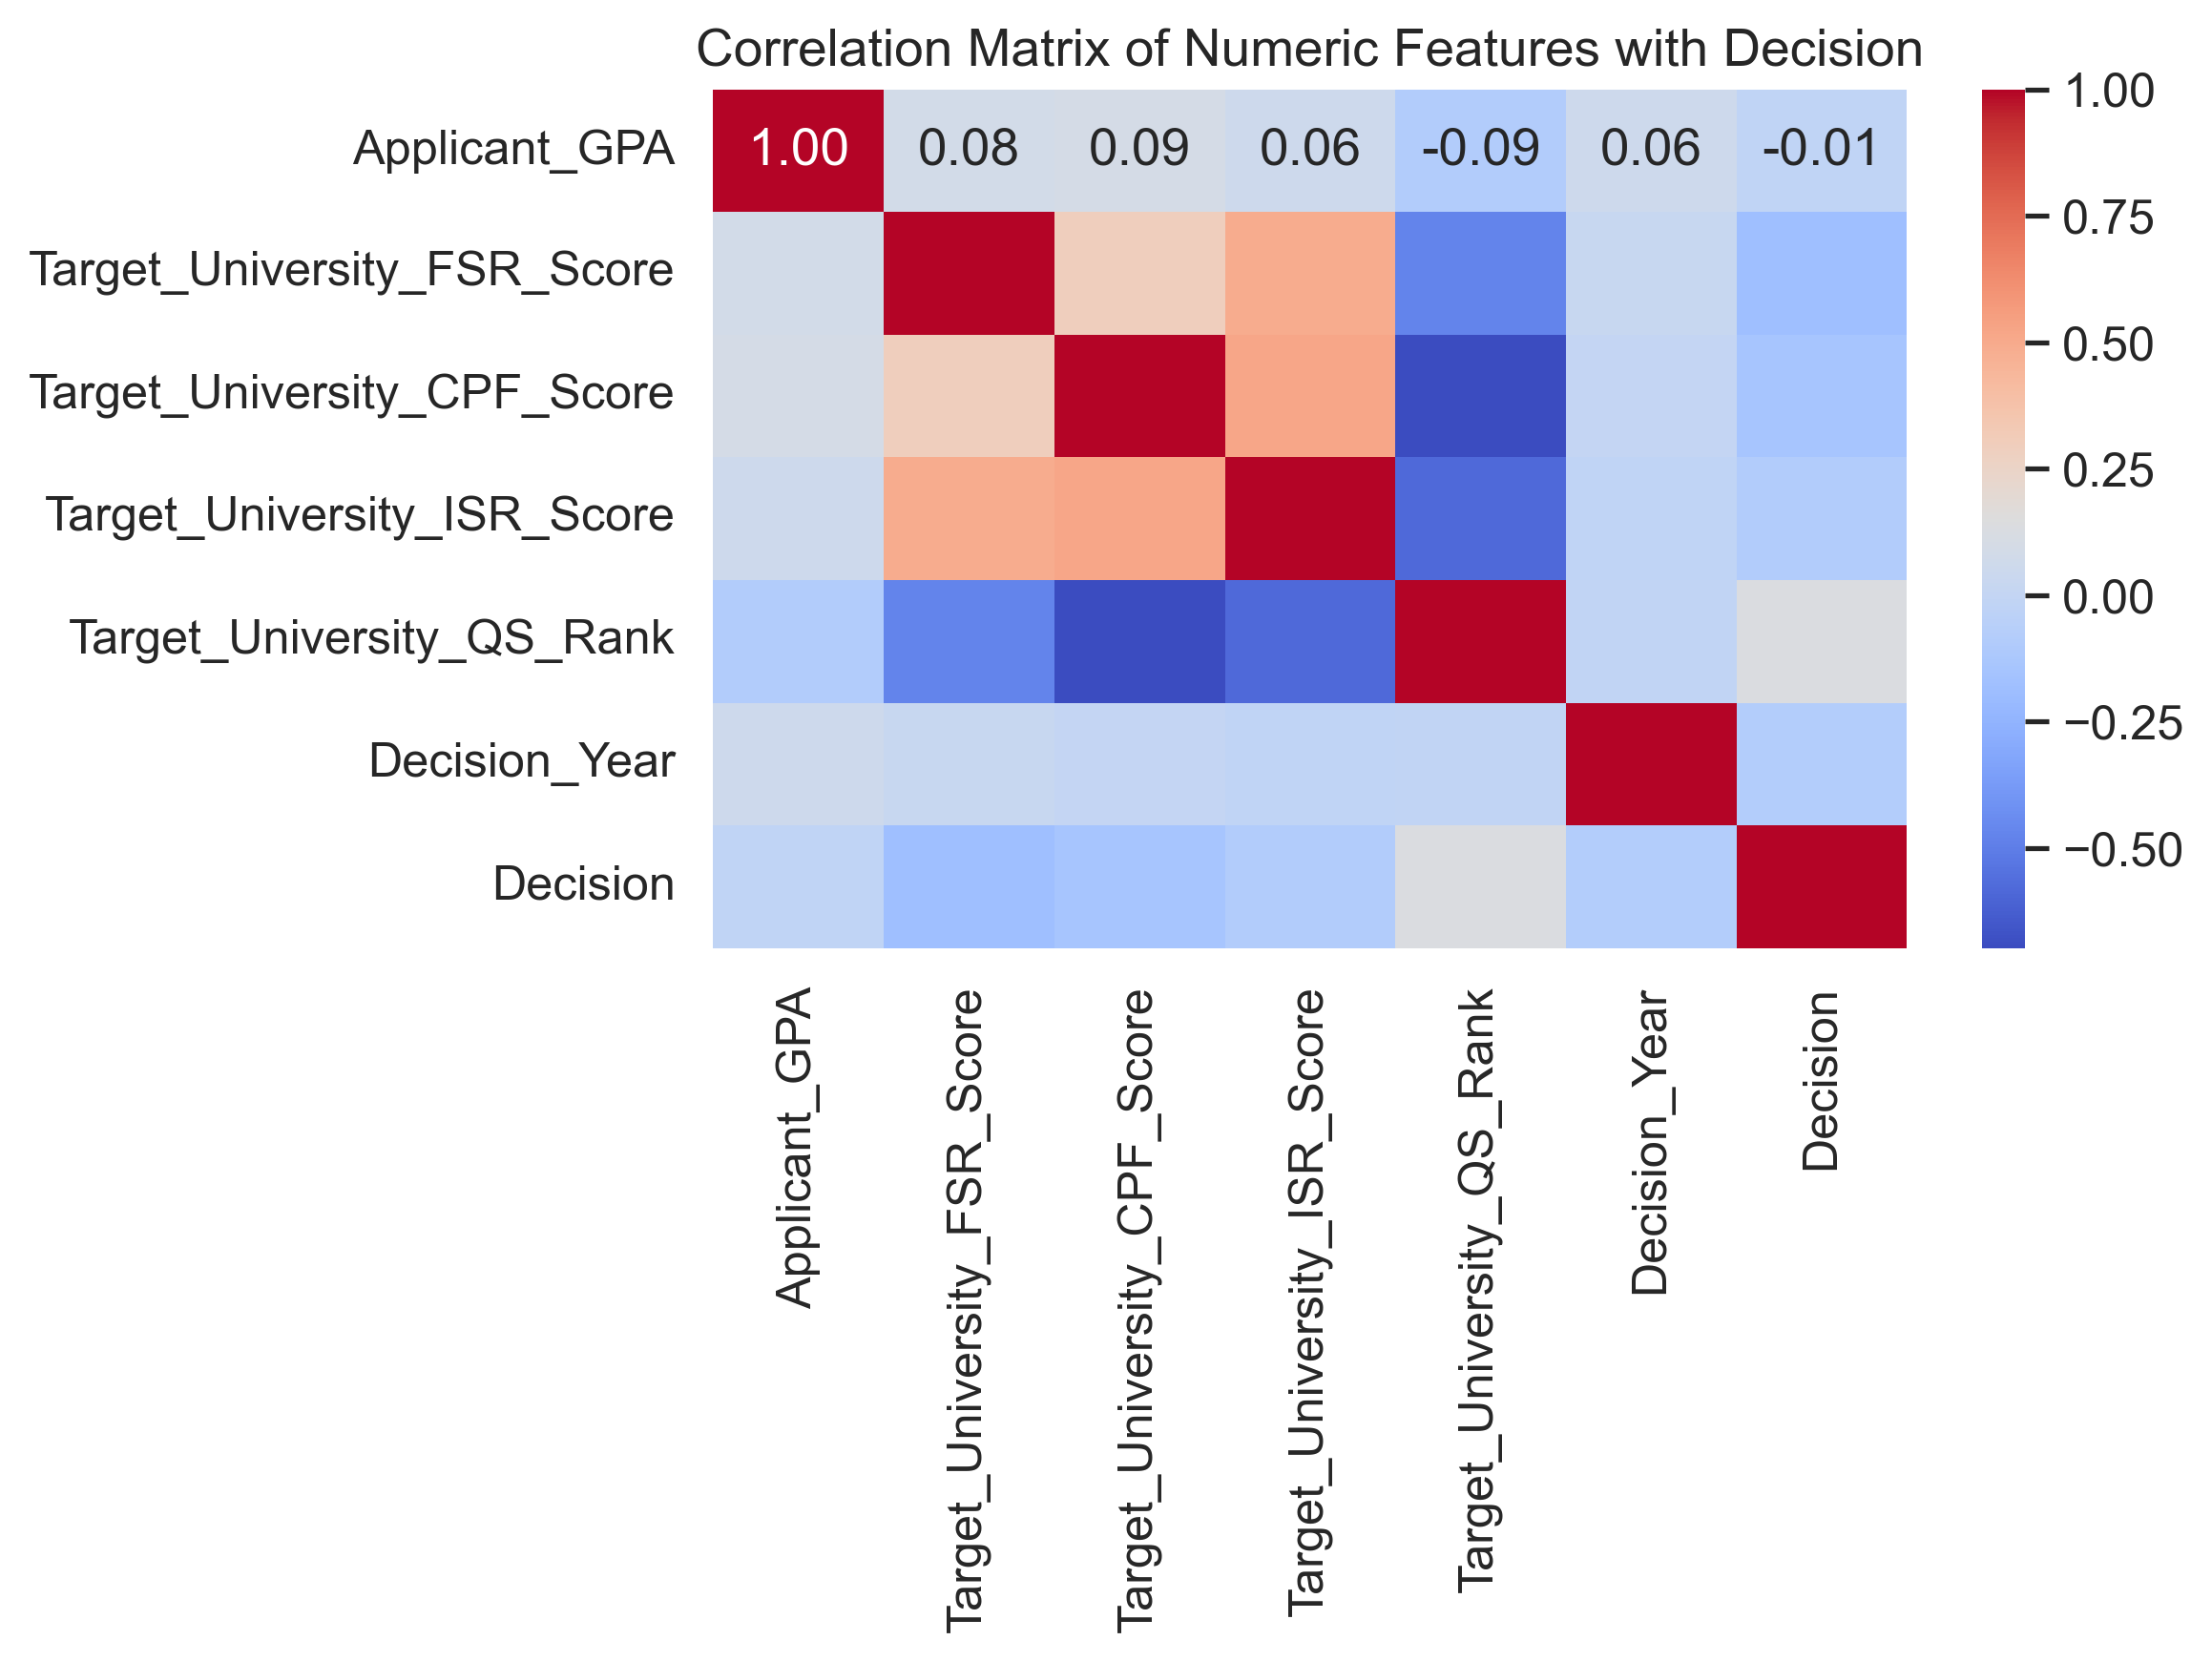

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ['Applicant_GPA', 'Target_University_FSR_Score', 
                    'Target_University_CPF_Score', 'Target_University_ISR_Score',
                    'Target_University_QS_Rank', 'Decision_Year']

plt.figure(figsize=(8,6))
corr_matrix = df[numeric_features + ['Decision']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features with Decision")
plt.tight_layout()
plt.show()
